In [54]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['PingFang SC']
plt.rcParams['axes.unicode_minus'] = False
import numpy as np
import pandas as pd
from scipy import stats

## step 1

In [16]:
data = pd.read_csv('cookie_cats.csv')

In [17]:
data.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [18]:
data.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [19]:
print(f'version_gate_30_sum:{data.loc[data['version']=='gate_30','version'].count()}')
print(f'version_gate_40_sum:{data.loc[data['version']=='gate_40','version'].count()}')

version_gate_40_sum:45489


In [20]:
data['retention_1'].value_counts()

retention_1
False    50036
True     40153
Name: count, dtype: int64

In [21]:
data['retention_7'].value_counts()

retention_7
False    73408
True     16781
Name: count, dtype: int64

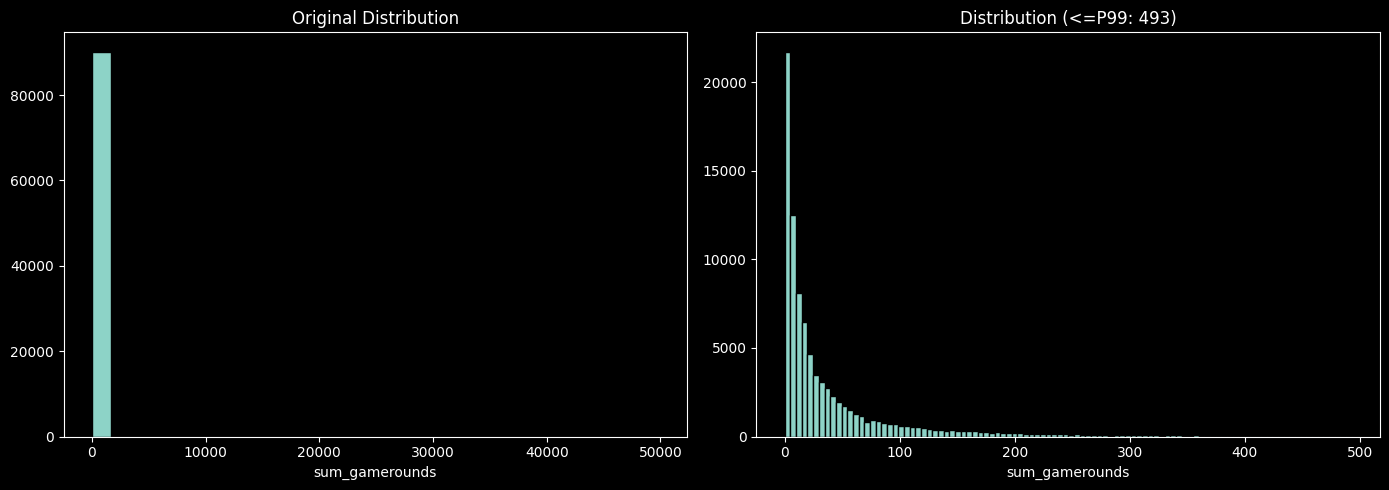

In [22]:
fig,axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data['sum_gamerounds'],bins=30,edgecolor='black' )
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('sum_gamerounds')

p99 = data['sum_gamerounds'].quantile(0.99)
axes[1].hist(data[data['sum_gamerounds'] <= p99]['sum_gamerounds'], bins=100, edgecolor='black')
axes[1].set_title(f'Distribution (<=P99: {p99:.0f})')
axes[1].set_xlabel('sum_gamerounds')
plt.tight_layout()
plt.show()

In [23]:
print(data['sum_gamerounds'].describe())
print(f"\nP95: {data['sum_gamerounds'].quantile(0.95):.0f}")
print(f"P99: {data['sum_gamerounds'].quantile(0.99):.0f}")
print(f"Max: {data['sum_gamerounds'].max()}")
print(f"零回合玩家数: {(data['sum_gamerounds'] == 0).sum()}")

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

P95: 221
P99: 493
Max: 49854
零回合玩家数: 3994


In [24]:
data['round_group'] = pd.cut(
    data['sum_gamerounds'],
    bins=[0,10,50,100,500,np.inf],
    right=False
)

## Step 2

In [25]:
print(f'一日留存率: {data['retention_1'].mean():.2f}')
print(f'七日留存率: {data['retention_7'].mean():.2f}')

一日留存率: 0.45
七日留存率: 0.19


In [26]:
retention = data.groupby('version')[['retention_1', 'retention_7']].mean()
print(retention)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


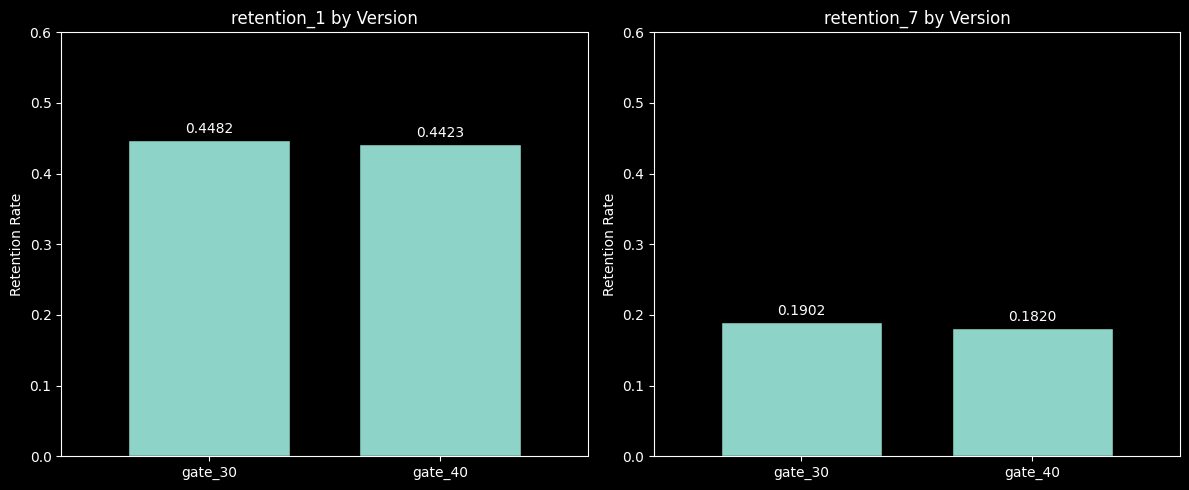

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i,col in enumerate(retention.columns):
    axes[i].bar(retention.index,retention[col],edgecolor='black',width=0.7)
    axes[i].set_title(f'{col} by Version')
    axes[i].set_ylabel('Retention Rate')
    axes[i].margins(x=0.17)
    axes[i].set_ylim(0,0.6)
    for v,j in enumerate(retention[col]):
        axes[i].text(v,j+0.01,f'{j:.4f}',ha='center')
plt.tight_layout()
plt.show()

In [45]:
#独立性检验
for col in ['retention_1','retention_7']:
    table = pd.crosstab(data['version'],data[col])
    chi2,p_value,dof,_ = stats.chi2_contingency(table,correction=False)
    V = np.sqrt(chi2/len(data)/1)
    print(f'{col}_chi2:{chi2:.3f}')
    print(f'{col}_p:{p_value:.3f}')
    print(f'{col}_V:{V:.3f}')
    print('\n')

retention_1_chi2:3.183
retention_1_p:0.074
retention_1_V:0.006


retention_7_chi2:10.013
retention_7_p:0.002
retention_7_V:0.011




In [48]:
#ks-test
rounds_30 = data.loc[data['version']=='gate_30','sum_gamerounds']
rounds_40 = data.loc[data['version']=='gate_40','sum_gamerounds']
ks,p = stats.ks_2samp(rounds_30,rounds_40)
ks,p

(np.float64(0.010270735856046653), np.float64(0.01707004050286604))

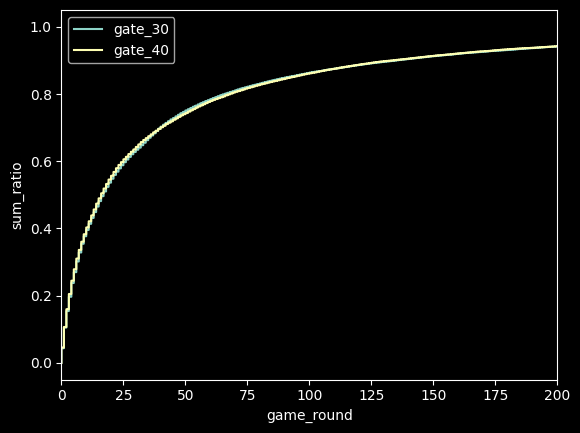

In [56]:
for label,data_group in [('gate_30',rounds_30),('gate_40',rounds_40)]:
    x = np.sort(data_group)
    y = np.arange(1,len(x)+1)/len(x)
    plt.step(x, y, label=label)

plt.xlim(0, 200)
plt.xlabel('game_round')
plt.ylabel('sum_ratio')
plt.legend()
plt.show()

In [60]:
#贝叶斯 A-B test
from scipy.stats import beta
a_30 = data[data['version']=='gate_30']
a_40 = data[data['version']=='gate_40']

k30, n30 = a_30['retention_7'].sum(), len(a_30)
k40, n40 = a_40['retention_7'].sum(), len(a_40)

np.random.seed(42)
samples_30 = np.random.beta(1+k30, 1+n30-k30, 100000)
samples_40 = np.random.beta(1+k40, 1+n40-k40, 100000)
prob_30_better = (samples_30 > samples_40).mean()
diff = samples_30 - samples_40
print(f'P(gate_30 > gate_40) = {prob_30_better:.2%}')
print(f'平均提升 = {diff.mean():.4f}')
print(f'95% 可信区间: [{np.percentile(diff, 2.5):.4f}, {np.percentile(diff, 97.5):.4f}]')

P(gate_30 > gate_40) = 99.91%
平均提升 = 0.0082
95% 可信区间: [0.0031, 0.0133]


## Step 3

## 结论

### 分析结果汇总

| 指标 | 方法 | 关键结果 |
|------|------|----------|
| retention_1 | 卡方检验 | chi2=3.18, p=0.074, V=0.006 |
| retention_7 | 卡方检验 | chi2=10.01, p=0.002, V=0.011 |
| retention_7 | 贝叶斯 A/B | P(gate_30 > gate_40) = 99.91%,95% CI [0.31pp, 1.33pp] |
| sum_gamerounds | KS 检验 + CDF | 两组分布几乎重合 |

### 业务结论

**gate_30 优于 gate_40**,效应集中在 **7 日留存**:

1. **1 日留存无显著差异**:p=0.074,玩家次日是否回来不受关卡位置影响
2. **7 日留存显著更高**:gate_30 平均提升 0.82pp,有 99.91% 的概率真实表现优于 gate_40
3. **游戏深度无差异**:两组玩家游戏轮数分布重合,关卡位置不改变游戏行为模式,仅影响用户是否持续回来

### 建议

**保留 gate_30,不推进 gate_40 改动**。

- 统计显著且效应量在业务上可接受(大样本下 0.82pp 对应可观的用户数)
- 改动零收益,反而损失长期留存
- gate_40 延迟的关卡墙可能削弱了早期用户的粘性节点

### 方法论说明

效应量 V ≈ 0.011 虽小,但样本量 9 万足以稳定检出。频率派(p 值)与贝叶斯(P(A>B))结论一致,后者给出的可信区间不跨零,可直接支撑业务决策。
